# Jasmin Experiments

Notebook orchestration only. Shared implementation lives in `src/`.

In [43]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.common.config import load_config
from src.common.data import SpacepressoDataModule
from src.common.evaluation import evaluate_predictions
from src.common.paths import resolve_path
from src.common.seed import set_seed
from src.common.submission import SubmissionWriter, validate_submission
from src.common.training import ExperimentRunner
from src.common.validation import make_validation_split
from src.common.visualization import show_predictions
from src.methods import get_method_class

In [44]:
config = load_config(ROOT / "configs/patchcore_lite/jasmin_test.yaml")
set_seed(config.get("seed", 42))

local_data = ROOT / "data" / "spacepresso"
if local_data.exists():
    config["data"]["root"] = str(local_data)
config["data"]["load_images"] = False

# --- Toggles ---
NO_BACKGROUND = True  # zero out outer black background in predictions
BG_DILATION   = 16    # pixels to keep around the object border
BG_THRESHOLD  = 0.20  # default threshold (pixels below this = background)
BG_THRESHOLD_PER_CLASS = {
    "class_01": 0.40,  # brownish background needs higher threshold
    "class_08": 0.40,  # brownish background needs higher threshold
}

def get_bg_threshold(class_name):
    return BG_THRESHOLD_PER_CLASS.get(class_name, BG_THRESHOLD)

dm = SpacepressoDataModule(**config["data"])
train_good = dm.load_train_good()
train_anomalies = dm.load_train_anomalies()
test = dm.load_test()
print({"train_good": len(train_good), "train_anomalies": len(train_anomalies), "test": len(test)})

{'train_good': 19005, 'train_anomalies': 235, 'test': 5910}


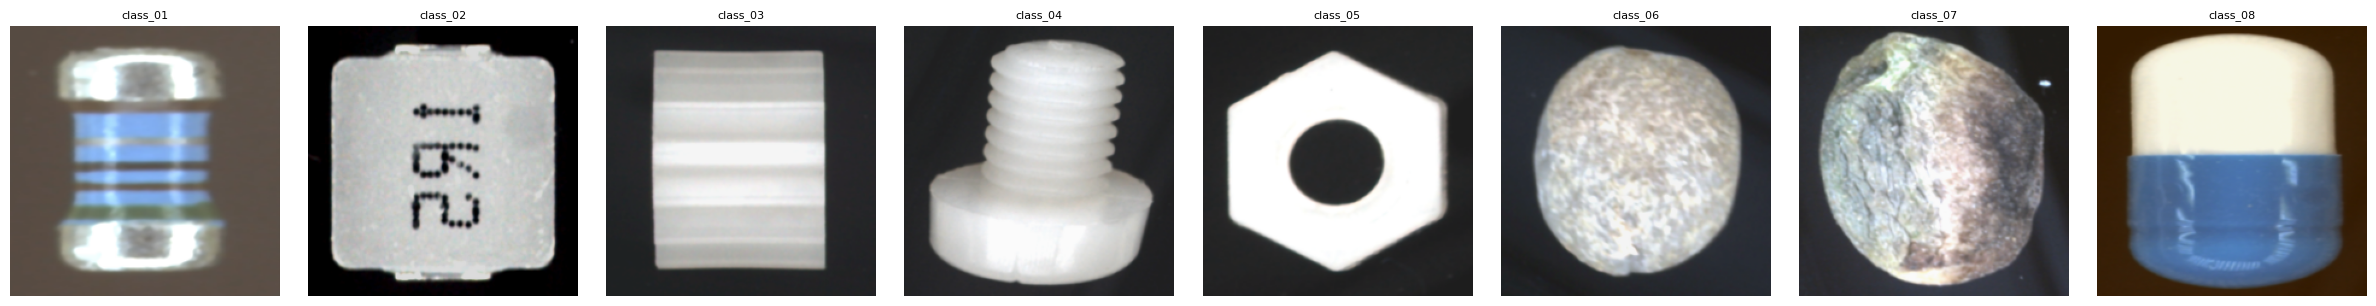

In [45]:
import matplotlib.pyplot as plt
from PIL import Image as PILImage
import numpy as np

classes = dm.list_classes()
fig, axes = plt.subplots(1, len(classes), figsize=(3 * len(classes), 3))
for ax, cls in zip(axes, classes):
    sample = next(s for s in train_good if s.class_name == cls)
    img = np.array(PILImage.open(sample.image_path).convert("RGB"))
    ax.imshow(img)
    ax.set_title(cls, fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

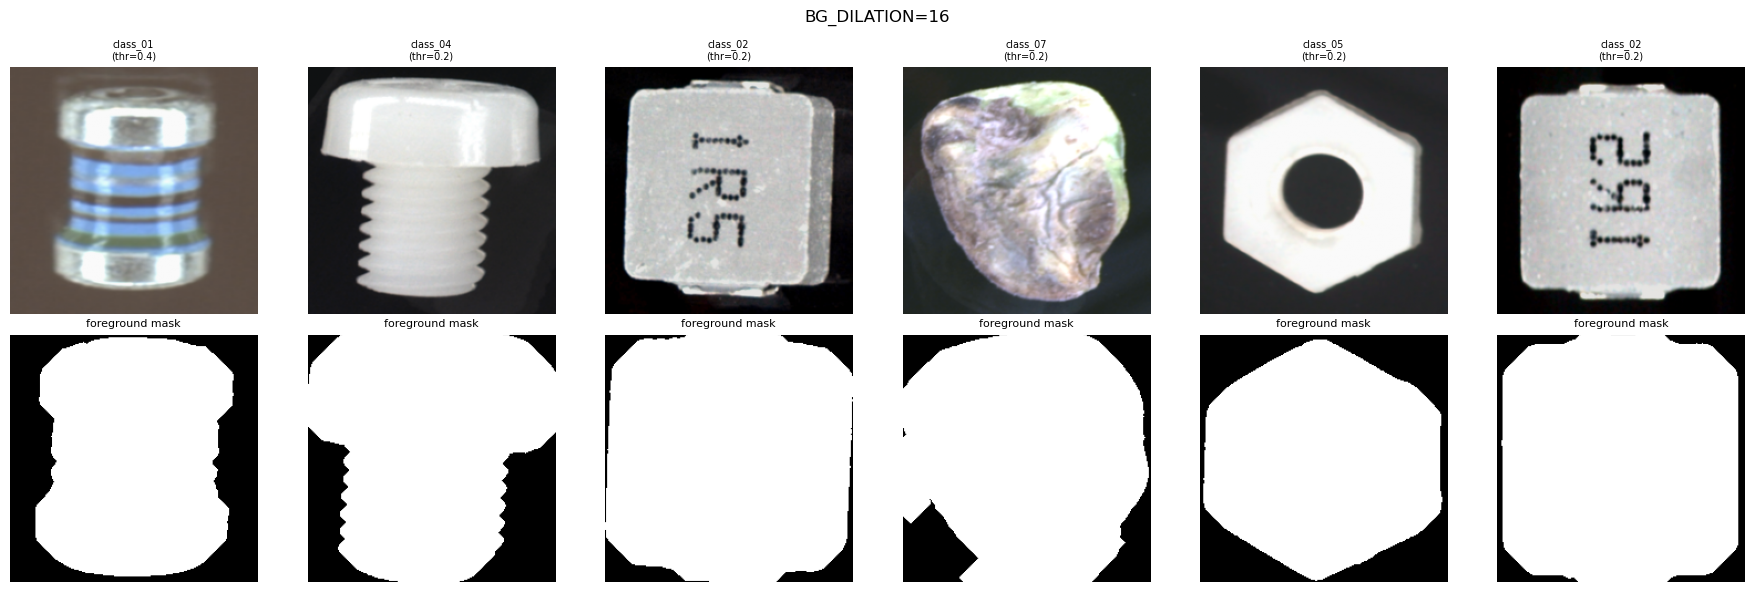

In [46]:
# Sanity check: visualize foreground masks on a few training images
if NO_BACKGROUND:
    import random
    import matplotlib.pyplot as plt
    from PIL import Image as PILImage
    import numpy as np
    from scipy.ndimage import binary_fill_holes, binary_dilation as _bdilate

    def _preview_foreground_mask(image_np, threshold, dilation):
        gray = image_np.mean(axis=2)
        fg = binary_fill_holes(gray > threshold)
        if dilation > 0:
            fg = _bdilate(fg, iterations=dilation)
        return fg.astype(np.float32)

    samples = random.sample(train_good, 6)
    fig, axes = plt.subplots(2, 6, figsize=(18, 6))
    for col, sample in enumerate(samples):
        img = np.array(PILImage.open(sample.image_path).convert("RGB").resize((config["data"]["image_size"], config["data"]["image_size"]))) / 255.0
        threshold = get_bg_threshold(sample.class_name)
        mask = _preview_foreground_mask(img, threshold, BG_DILATION)
        axes[0, col].imshow(img)
        axes[0, col].set_title(f"{sample.class_name}\n(thr={threshold})", fontsize=7)
        axes[0, col].axis("off")
        axes[1, col].imshow(mask, cmap="gray", vmin=0, vmax=1)
        axes[1, col].set_title("foreground mask", fontsize=8)
        axes[1, col].axis("off")
    plt.suptitle(f"BG_DILATION={BG_DILATION}")
    plt.tight_layout()
    plt.show()

Using PatchCore backbone: wide_resnet50_2
Fitting PatchCore memory bank for class_01: 2600 images


PatchCore feature extraction: 100%|██████████| 650/650 [00:24<00:00, 26.92it/s]


Seen bank: 2,038,400 patches x 1536 dims; candidate pool: 6,000 patches; coreset: 2,000 patches
Fitting PatchCore memory bank for class_02: 2135 images


PatchCore feature extraction: 100%|██████████| 534/534 [00:21<00:00, 24.56it/s]


Seen bank: 1,673,840 patches x 1536 dims; candidate pool: 6,000 patches; coreset: 2,000 patches
Fitting PatchCore memory bank for class_03: 2520 images


...

PatchCore feature extraction: 100%|██████████| 537/537 [00:20<00:00, 26.29it/s]


Seen bank: 1,681,680 patches x 1536 dims; candidate pool: 6,000 patches; coreset: 2,000 patches
Fitting PatchCore memory bank for class_08: 2045 images


PatchCore feature extraction: 100%|██████████| 512/512 [00:19<00:00, 26.90it/s]


Seen bank: 1,603,280 patches x 1536 dims; candidate pool: 6,000 patches; coreset: 2,000 patches


PatchCore inference: 100%|██████████| 240/240 [00:24<00:00,  9.94it/s]


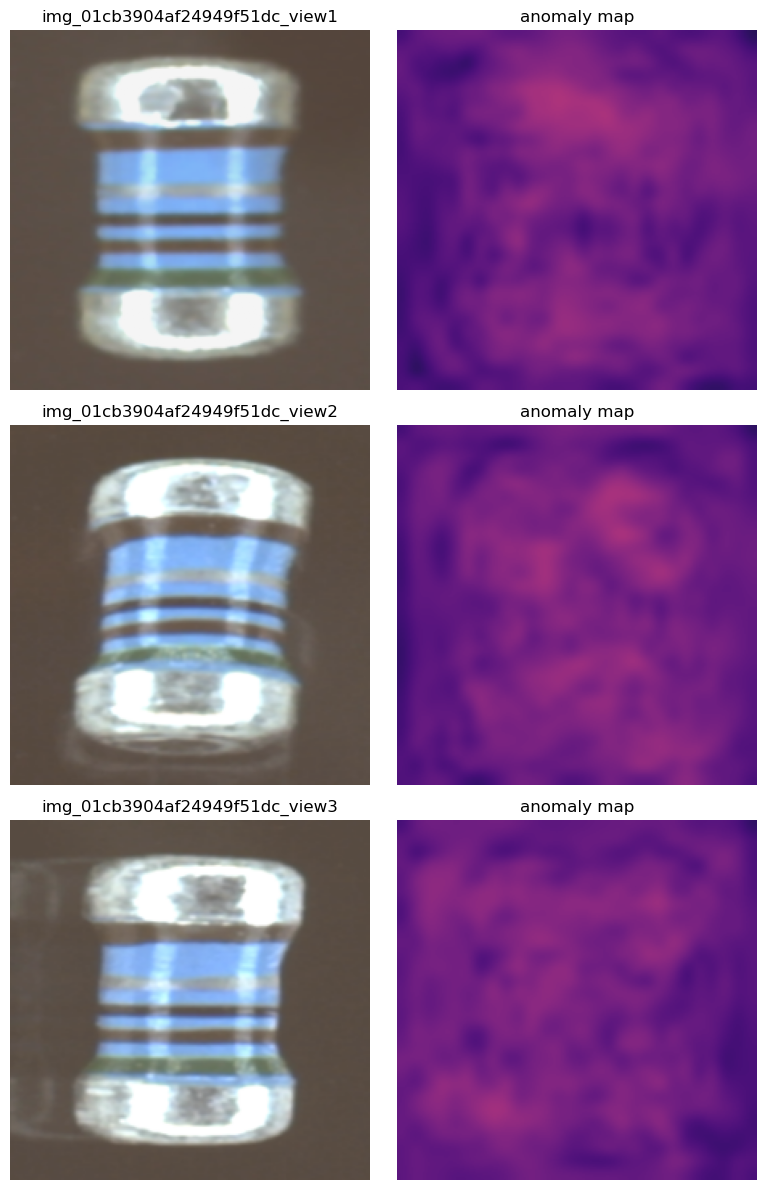

In [48]:
if train_good and test:
    Method = get_method_class(config["method"]["name"])
    runner = ExperimentRunner(Method(config), config)
    runner.fit(train_good)
    predictions = runner.predict(test)
    show_predictions(test, predictions, n=3)
else:
    predictions = {}
    print("Dataset is empty or not found. Update config['data']['root'] before running.")


In [ ]:
# Validation: evaluate on all 235 anomalies + a sample of good images
if predictions:
    import random as _random
    N_GOOD_VAL = 200  # number of good images to include (checks false positive rate)

    good_sample = _random.sample(train_good, min(N_GOOD_VAL, len(train_good)))
    val_samples = train_anomalies + good_sample
    val_predictions = runner.predict(val_samples)

    if NO_BACKGROUND:
        from PIL import Image as PILImage
        from scipy.ndimage import binary_fill_holes, binary_dilation as _bdilate
        import numpy as np
        id_to_sample = {s.image_id: s for s in val_samples}
        image_size = config["data"]["image_size"]
        for img_id, pred in val_predictions.items():
            s = id_to_sample[img_id]
            threshold = get_bg_threshold(s.class_name)
            img = np.array(PILImage.open(s.image_path).convert("RGB").resize((image_size, image_size))) / 255.0
            fg = binary_fill_holes(img.mean(axis=2) > threshold)
            if BG_DILATION > 0:
                fg = _bdilate(fg, iterations=BG_DILATION)
            val_predictions[img_id] = pred * fg.astype(np.float32)

    metrics = evaluate_predictions(val_samples, val_predictions).as_dict()
    print(f"Evaluated on {len(train_anomalies)} anomalies + {len(good_sample)} good images")
    print(f"Pixel AP:    {metrics['pixel_ap']:.4f}")
    print(f"Image AP:    {metrics['image_ap']:.4f}")
    print(f"Pixel AUROC: {metrics['pixel_auroc']:.4f}")

In [49]:
# Background suppression: zero out outer black background in each prediction map
if NO_BACKGROUND and predictions:
    from PIL import Image as PILImage
    from scipy.ndimage import binary_fill_holes, binary_dilation as _bdilate
    import numpy as np

    image_size = config["data"]["image_size"]
    id_to_sample = {s.image_id: s for s in test}

    for img_id, pred in predictions.items():
        sample = id_to_sample[img_id]
        threshold = get_bg_threshold(sample.class_name)
        img = np.array(PILImage.open(sample.image_path).convert("RGB").resize((image_size, image_size))) / 255.0
        fg = binary_fill_holes(img.mean(axis=2) > threshold)
        if BG_DILATION > 0:
            fg = _bdilate(fg, iterations=BG_DILATION)
        predictions[img_id] = pred * fg.astype(np.float32)

    print("Background suppression applied.")

Background suppression applied.


In [ ]:
if predictions:
    import zipfile, random
    from datetime import datetime
    from src.common.submission import _prepare_prediction_map
    from src.common.q8rle import float_matrix_to_q8rle, q8rle_to_float_matrix

    expected_shape = (config["data"]["image_size"], config["data"]["image_size"])
    sorted_ids = sorted(predictions)
    assert len(sorted_ids) == len(test), f"Expected {len(test)} predictions, got {len(sorted_ids)}"

    sample_indices = set(random.sample(range(len(sorted_ids)), min(5, len(sorted_ids))))
    sampled_labels = {}

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    base_path = resolve_path(config["submission"]["output_path"], ROOT)
    zip_path = base_path.parent / f"{base_path.stem}_{timestamp}.zip"
    zip_path.parent.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED, compresslevel=6) as zf:
        with zf.open(base_path.stem + ".csv", "w") as f:
            f.write(b"ID,Label\n")
            for i, img_id in enumerate(sorted_ids):
                label = float_matrix_to_q8rle(_prepare_prediction_map(predictions[img_id]))
                f.write(f"{img_id},{label}\n".encode("utf-8"))
                if i in sample_indices:
                    sampled_labels[img_id] = label

    for img_id, label in sampled_labels.items():
        assert label.startswith("q8rle"), f"Bad label for {img_id}"
        assert q8rle_to_float_matrix(label).shape == expected_shape, f"Shape mismatch for {img_id}"

    print(f"Validated: {len(sorted_ids)} rows, spot-checked {len(sampled_labels)}, shape {expected_shape}")
    print(f"Saved: {zip_path} ({zip_path.stat().st_size / 1024**2:.1f} MB)")